# Generating Images with a Normalizing Flow

In the [normalizing flows session](../sessions/flow.ipynb) we fitted a masked autoregressive flow to a
two-dimensional toy dataset and to the six-dimensional UCI POWER benchmark, and we used it for two things:
evaluating an exact density, and drawing samples.

Here we point the same model at **images**, and use the sampling direction as an image generator.
MNIST digits are 28x28 = 784-dimensional, which is a jump of two orders of magnitude from POWER.

The exercise has two parts, and the second one exists because of what happens in the first:

1. **A flow on raw pixels.** We fit the flow to all 784 pixel dimensions, measure its likelihood in
   *bits per dimension* -- the standard unit for image density models -- and then look at its samples.
2. **A flow on autoencoder codes.** We fit the same kind of flow to the 32-dimensional latent codes of the
   dense autoencoder from the [autoencoders session](../sessions/autoencoders.ipynb), and decode its samples
   back into images.

Most of the code is given. You fill in the four cells marked **Your turn**, and answer the questions at the end.

> **Before you start:** part 2 loads the autoencoder trained in the
> [autoencoders session](../sessions/autoencoders.ipynb). Run that notebook first, at least as far as the
> latent-dimension sweep that saves `../data/autoencoder_dense_32_encoder.keras` and
> `../data/autoencoder_dense_32_decoder.keras`. Those checkpoints are not in the repository.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from jax import random
import flowjax
import flowjax.bijections
import flowjax.distributions
import flowjax.flows
import flowjax.train
import keras

sns.set(style='white', context='talk')
SEED = 130
rng = np.random.default_rng(SEED)

print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())
print('FlowJAX:', flowjax.__version__)

Keras: 3.15.1 backend: jax gpu
FlowJAX: 19.1.1


## The data

(60000, 28, 28) (10000, 28, 28) uint8 0 255


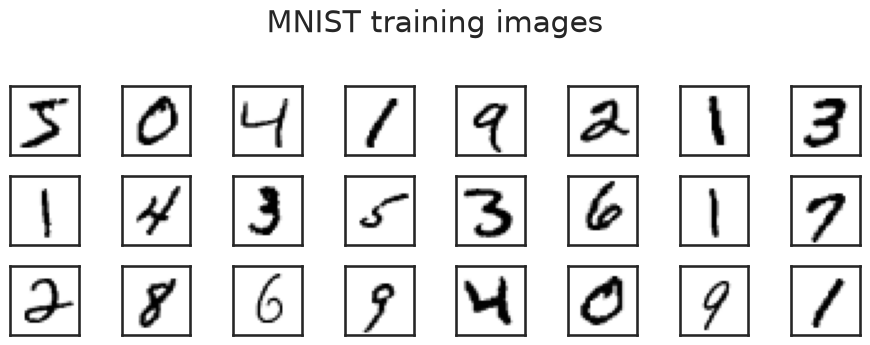

In [2]:
(X_train, Y_train), (X_validation, Y_validation) = keras.datasets.mnist.load_data()
print(X_train.shape, X_validation.shape, X_train.dtype, X_train.min(), X_train.max())

def show_grid(images, title='', n_cols=8):
    """Draw a row-major grid of 28x28 images in [0, 1]."""
    images = np.asarray(images).reshape(-1, 28, 28)
    n_rows = int(np.ceil(len(images) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.15 * n_cols, 1.2 * n_rows))
    for ax, image in zip(axes.ravel(), images):
        ax.imshow(image, cmap='gray_r', vmin=0, vmax=1)
    for ax in axes.ravel():
        ax.set(xticks=[], yticks=[])
    fig.suptitle(title)
    fig.tight_layout()

show_grid(X_train[:24] / 255, title='MNIST training images')

# Part 1: a flow on raw pixels

## Pixels are not POWER: two things have to be fixed first

A flow puts a *continuous* density on $\mathbb{R}^D$. MNIST pixels are neither continuous nor unbounded,
and both facts break the model if we ignore them.

**Pixels are discrete.** Every pixel is an integer in $\{0, \dots, 255\}$, so the data lives on a lattice.
A continuous density can pile arbitrarily tall spikes on a lattice and drive the likelihood to $+\infty$
without learning anything -- exactly the failure the POWER session dequantized away, and much worse here,
because most MNIST pixels are *exactly* 0. So we **dequantize**: add uniform noise of one quantization step,
$$
v = \frac{x + u}{256}, \qquad u \sim U[0, 1)^{784},
$$
which spreads each reported integer over the interval it actually stands for, and puts $v$ in $[0, 1)^{784}$.

**Pixels are bounded.** $v$ lives in the unit cube, and our base distribution is a Gaussian on all of
$\mathbb{R}^{784}$. Squeezing an unbounded density into a cube means piling up mass at the faces.
The standard fix is a **logit transform**, with a small $\alpha$ to keep the transform finite at $v = 0$ and $v = 1$:
$$
y = \operatorname{logit}\big(\alpha + (1 - 2\alpha) v\big), \qquad \alpha = 0.05 .
$$

We fit the flow to $y$. Both steps are invertible with a tractable Jacobian, which is what lets us convert
the flow's likelihood back into a statement about the original images at the end.

(60000, 784) logit range -2.94 .. +2.94


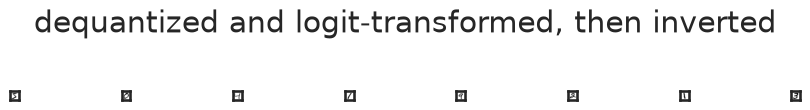

In [3]:
ALPHA = 0.05

def dequantize_logit(images_uint8, rng):
    """uint8 images -> (y, v): logit-space values to model, and the dequantized values in [0, 1)."""
    n = len(images_uint8)
    v = (images_uint8.reshape(n, -1).astype(np.float32) + rng.random((n, 784), dtype=np.float32)) / 256.0
    p = ALPHA + (1 - 2 * ALPHA) * v
    y = np.log(p) - np.log1p(-p)
    return y.astype(np.float32), v

def inverse_logit(y):
    """Back from logit space to pixel intensities in [0, 1], for plotting."""
    p = 1 / (1 + np.exp(-np.asarray(y)))
    return np.clip((p - ALPHA) / (1 - 2 * ALPHA), 0, 1)

Y_train, V_train = dequantize_logit(X_train, rng)
Y_validation, V_validation = dequantize_logit(X_validation, rng)
print(Y_train.shape, f'logit range {Y_train.min():+.2f} .. {Y_train.max():+.2f}')

# The transform is invertible: decoding the logit values reproduces the images.
show_grid(inverse_logit(Y_train[:8]), title='dequantized and logit-transformed, then inverted')

## The flow

This is the POWER flow from the session with one number changed -- the dimension. Same masked autoregressive
structure, same rational-quadratic spline transformer, same `fit_to_data` call.

`interval=6` because the logit transform with $\alpha = 0.05$ maps the data into $\pm 2.95$, and a spline is
pinned to the identity outside its box.

In [4]:
key = random.key(SEED)

key, subkey = random.split(key)
pixel_flow = flowjax.flows.masked_autoregressive_flow(
    subkey,
    base_dist=flowjax.distributions.Normal(jnp.zeros(784)),
    transformer=flowjax.bijections.RationalQuadraticSpline(knots=8, interval=6),
    flow_layers=4,
    nn_width=512,
    nn_depth=2,
)

Training is capped at 20 epochs to keep this to about three minutes on a GPU. That cap is *binding* --
the flow has not converged -- and we come back to what that does and does not excuse.

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:13<?, ?it/s, train=-772, val=-1.2e+3]

  5%|▌         | 1/20 [00:13<04:18, 13.59s/it, train=-772, val=-1.2e+3]

  5%|▌         | 1/20 [00:19<04:18, 13.59s/it, train=-1.26e+3, val=-1.3e+3]

 10%|█         | 2/20 [00:19<02:38,  8.80s/it, train=-1.26e+3, val=-1.3e+3]

...

 95%|█████████▌| 19/20 [01:52<00:05,  5.51s/it, train=-1.47e+3, val=-1.46e+3]

 95%|█████████▌| 19/20 [01:57<00:05,  5.51s/it, train=-1.48e+3, val=-1.43e+3]

100%|██████████| 20/20 [01:57<00:00,  5.55s/it, train=-1.48e+3, val=-1.43e+3]

100%|██████████| 20/20 [01:57<00:00,  5.90s/it, train=-1.48e+3, val=-1.43e+3]


trained for 20 epochs in 119s


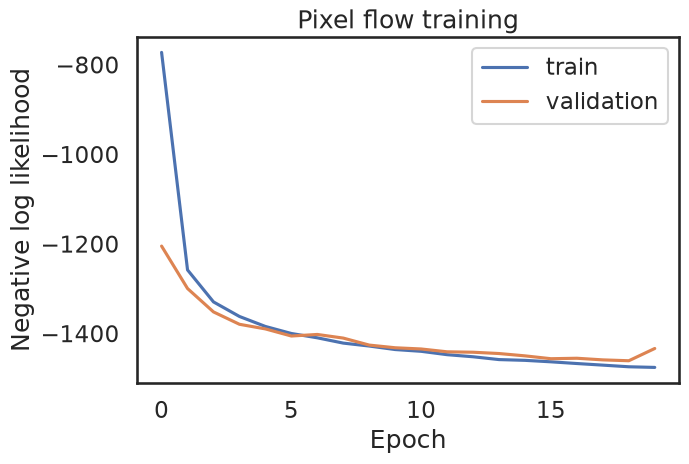

In [5]:
t0 = time.time()
key, subkey = random.split(key)
pixel_flow, pixel_losses = flowjax.train.fit_to_data(
    subkey,
    pixel_flow,
    jnp.asarray(Y_train),
    learning_rate=1e-3,
    batch_size=256,
    max_patience=8,
    max_epochs=20,
    show_progress=True,
)
print(f'\ntrained for {len(pixel_losses["train"])} epochs in {time.time() - t0:.0f}s')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pixel_losses['train'], label='train')
ax.plot(pixel_losses['val'], label='validation')
ax.set(title='Pixel flow training', xlabel='Epoch', ylabel='Negative log likelihood')
ax.legend();

## How good is the likelihood? Bits per dimension

Nats on the logit-transformed data are not comparable to anything, because the logit transform changed the
units. The unit every image density model reports is **bits per dimension**: the average number of bits needed
to encode one pixel of a held-out image. Lower is better, and 8 bits/dim is what you get by storing the raw
byte.

Getting there is two changes of variables, undoing what we did to the data:

$$
\log p_V(v) = \log p_Y(y) + \sum_{j} \log\left|\frac{\partial y_j}{\partial v_j}\right| ,
\qquad
\frac{\partial y_j}{\partial v_j} = \frac{1 - 2\alpha}{p_j (1 - p_j)} ,
$$

and then from the dequantized $v = (x + u)/256$ back to the discrete image, which contributes $-784 \log 256$:

$$
\text{bits/dim} = -\frac{\mathbb{E}_u[\log p_V(v)] - 784 \log 256}{784 \log 2} .
$$

For reference we also score a baseline that cannot generate anything at all: independent Gaussians, one fitted
per pixel, with no dependence between pixels whatsoever.

In [6]:
def logit_log_jacobian(v):
    """sum_j log |dy_j / dv_j| for the logit transform above."""
    p = ALPHA + (1 - 2 * ALPHA) * v
    return np.sum(np.log(1 - 2 * ALPHA) - np.log(p) - np.log1p(-p), axis=1)

def bits_per_dim(log_prob_y, v):
    log_p_v = log_prob_y + logit_log_jacobian(v)
    return -(log_p_v.mean() - 784 * np.log(256)) / (784 * np.log(2))

# Score in batches: 10,000 images at 784 dimensions at once is a lot of memory.
flow_log_prob = np.concatenate([
    np.asarray(pixel_flow.log_prob(jnp.asarray(Y_validation[i:i + 2000])))
    for i in range(0, len(Y_validation), 2000)
])
print(f'flow:                {bits_per_dim(flow_log_prob, V_validation):.3f} bits/dim')

# Baseline: one independent Gaussian per pixel, fitted in logit space.
mean, std = Y_train.mean(axis=0), Y_train.std(axis=0)
gaussian_log_prob = (-0.5 * ((Y_validation - mean) / std) ** 2 - np.log(std) - 0.5 * np.log(2 * np.pi)).sum(axis=1)
print(f'independent Gaussian: {bits_per_dim(gaussian_log_prob, V_validation):.3f} bits/dim')

flow:                1.319 bits/dim


independent Gaussian: 4.853 bits/dim


### Your turn (1): generate images

The flow is a distribution over logit-space vectors, so generating an image is three steps: sample, invert the
logit transform, reshape to 28x28. `show_grid` does the last one for you.

Draw 24 samples and display them. Use `pixel_flow.sample(subkey, (24,))`, and remember to split `key` first --
`flow.sample` takes a JAX key, exactly as in the session.

In [7]:
# Your code here


Before you read on, write down in one sentence what you expected the samples to look like, and what they
actually look like. Part 2 and the questions at the end are both about that gap.

# Part 2: a flow on autoencoder codes

Part 1 fitted a density to pixels directly, and pixels are a bad coordinate system to be generative in: 784
strongly dependent dimensions, most of which are background.

The [autoencoders session](../sessions/autoencoders.ipynb) already built a better coordinate system. Its dense
autoencoder compresses an image to a 32-dimensional code and reconstructs it, and reconstructions from those
codes look like digits. What the autoencoder does *not* give you is a way to generate: it has no distribution
over codes, so there is nothing to sample. Feeding the decoder an arbitrary vector gives an arbitrary picture.

That is precisely the missing piece a flow supplies. We fit a density to the codes, sample from it, and decode.

We load the encoder and decoder trained in that session -- 32 dimensions is the largest of the three latent
sizes it sweeps.

latent dimension: 32


(60000, 32) standardized range -5.19 .. +5.33


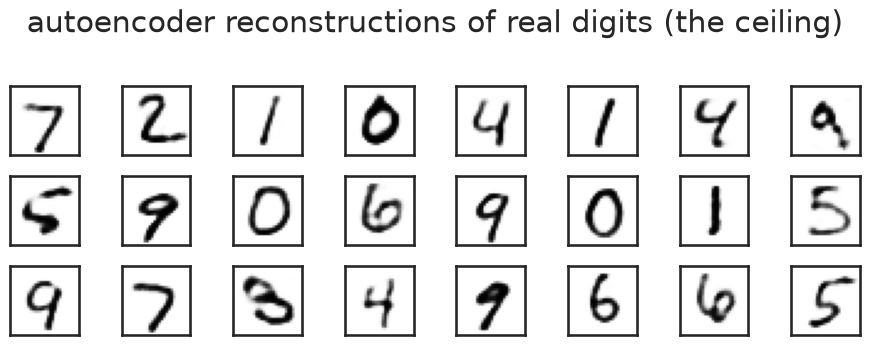

In [8]:
encoder = keras.models.load_model('../data/autoencoder_dense_32_encoder.keras')
decoder = keras.models.load_model('../data/autoencoder_dense_32_decoder.keras')
latent_dim = encoder.output_shape[-1]
print('latent dimension:', latent_dim)

Z_train = encoder.predict(X_train / 255, verbose=0)
Z_validation = encoder.predict(X_validation / 255, verbose=0)

# Standardize the codes. The encoder had no reason to produce anything near N(0, 1),
# and a spline transformer needs its data inside the interval it is defined on.
z_mean, z_std = Z_train.mean(axis=0), Z_train.std(axis=0)
Z_train = ((Z_train - z_mean) / z_std).astype(np.float32)
Z_validation = ((Z_validation - z_mean) / z_std).astype(np.float32)
print(Z_train.shape, f'standardized range {Z_train.min():+.2f} .. {Z_train.max():+.2f}')

# The reconstruction ceiling: the best any code-space generator could possibly look.
show_grid(decoder.predict(Z_validation[:24] * z_std + z_mean, verbose=0),
          title='autoencoder reconstructions of real digits (the ceiling)')

### Your turn (2): a flow on the codes

Build a flow for the 32-dimensional codes and fit it, mirroring the POWER flow in the session.

Reasonable settings, which is roughly the POWER configuration: `RationalQuadraticSpline(knots=8, interval=5)`,
`flow_layers=8`, `nn_width=128`, `nn_depth=2`; then `fit_to_data` with `learning_rate=1e-3`, `batch_size=256`,
`max_patience=15`, `max_epochs=300`. Call the fitted flow `latent_flow`. It takes about two minutes, and unlike
part 1 the epoch cap is *not* binding -- early stopping fires on its own.

Then print its mean log-likelihood on `Z_validation`.

In [9]:
# Your code here


### Your turn (3): decode the samples

Sample 24 codes from `latent_flow`, undo the standardization (`z * z_std + z_mean`), push them through
`decoder.predict`, and show them with `show_grid`.

In [10]:
# Your code here


### Your turn (4): the control

The samples in part 1 were bad and these are good, but we have changed *two* things at once: the flow now
works in 32 dimensions instead of 784, and there is a decoder in the way. Maybe the decoder is doing all the
work, and any old distribution over codes would do.

So run the control. Fit a **full-covariance Gaussian** to the same standardized codes `Z_train`, draw 24
samples from it, and decode them through the **same** decoder. `rng.multivariate_normal(mean, cov, size=24)`
with `np.cov(Z_train, rowvar=False)` is all you need.

Score it too: the Gaussian's mean log-likelihood on `Z_validation`, next to the flow's. The formula is in the
POWER section of the session notebook (`gaussian_log_likelihood`).

In [11]:
# Your code here


# Questions

1. **The central one.** The pixel flow's likelihood is genuinely good -- far better than the per-pixel Gaussian,
   and in the range that published flow papers report for MNIST -- and a large share of its samples are not
   digits. How can a model be right about the density and unreliable about what the data looks like? (Hint: a log-likelihood is an
   average over the *data*. It says how much mass the model puts where the data is. It says nothing about where
   else the model puts mass, and in 784 dimensions there is a great deal of "else".)

2. **Is it just undertrained?** The 20-epoch cap in part 1 is binding. Before blaming it, predict what you would
   expect from training four times longer, then decide what evidence would settle it. (If you have the time:
   raise `max_epochs` to 100 and `max_patience` to 8 and let early stopping fire.)

3. **What did the control show?** Compare the three grids -- flow-over-codes, Gaussian-over-codes, and the
   reconstruction ceiling -- and the two log-likelihoods. Which part of the pipeline is responsible for the good
   samples in part 2, the decoder or the density? How do you know?

4. **Ordering.** A masked autoregressive flow factorizes $p(x) = \prod_j p(x_j \mid x_{<j})$ in a fixed
   coordinate order. For POWER the order of the six columns was arbitrary but harmless. For an image, the
   "order" is raster-scan over pixels. What does conditioning pixel $j$ on all previous pixels in raster order
   mean geometrically, and which pixels that are obviously relevant to $x_j$ end up far away in that ordering?

5. **Bits per dimension.** Our flow is around 1.3 bits/dim; storing the raw byte costs 8. Why is a *density
   model* a lossless compression scheme, and what would 0 bits/dim mean?

# Further exercises

1. **Fashion-MNIST.** Re-run both parts on `keras.datasets.fashion_mnist`. The images have the same shape, so
   the only thing that changes is the autoencoder -- retrain it with `build_dense_autoencoder` from the
   autoencoders session. Are the pixel-space samples worse than for MNIST, and is the gap between the flow and
   the Gaussian over codes bigger or smaller?

2. **Latent size.** The autoencoders session also saves 2- and 8-dimensional encoders. Fit a flow to each and
   compare the decoded samples. A smaller code is easier to model and reconstructs worse -- where is the best
   trade-off, and how would you measure "best" without looking at the pictures?

3. **Interpolate.** Take two validation images, encode them, and decode a straight line between their codes.
   Then do the same in the flow's *base* space: map both codes to $z$ with `latent_flow.bijection.inverse`,
   interpolate there, and map back with `.transform`. The second path stays in high-density regions and the
   first need not. Do they look different?

4. **Truncation.** Sample the base Gaussian with a standard deviation of 0.7 instead of 1 before pushing it
   through `latent_flow.bijection.transform`, and decode. This is the flow version of the truncation trick used
   in GAN sampling. Sample quality and sample diversity move in opposite directions -- which do you prefer?

5. **A convolutional code.** The autoencoders session also trains a *convolutional* autoencoder. Its codes are
   a feature map rather than a vector; flatten them and fit a flow. Does the better reconstruction ceiling
   translate into better samples?

# References

1. Papamakarios, Pavlakou & Murray (2017), [*Masked Autoregressive Flow for Density Estimation*](https://arxiv.org/abs/1705.07057), NeurIPS. Table 2 reports MNIST in bits/dim, for the *conditional* case.
2. Uria, Murray & Larochelle (2013), [*RNADE: The real-valued neural autoregressive density-estimator*](https://arxiv.org/abs/1306.0186), NeurIPS. Section 3.1 is the standard reference for why discrete data must be dequantized before a continuous density is fitted to it.
3. Theis, van den Oord & Bethge (2016), [*A note on the evaluation of generative models*](https://arxiv.org/abs/1511.01844), ICLR. The paper behind question 1: log-likelihood and sample quality are close to independent in high dimensions, and a model can be excellent at one and useless at the other.
4. Dinh, Sohl-Dickstein & Bengio (2017), [*Density estimation using Real NVP*](https://arxiv.org/abs/1605.08803), ICLR. Where the logit transform of image data used here comes from (Section 4.1), and the multi-scale convolutional architecture that makes pixel-space flows actually generate images.
5. Kingma & Dhariwal (2018), [*Glow: Generative Flow with Invertible 1x1 Convolutions*](https://arxiv.org/abs/1807.03039), NeurIPS. What a flow that really can generate images looks like.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)